# **Task-01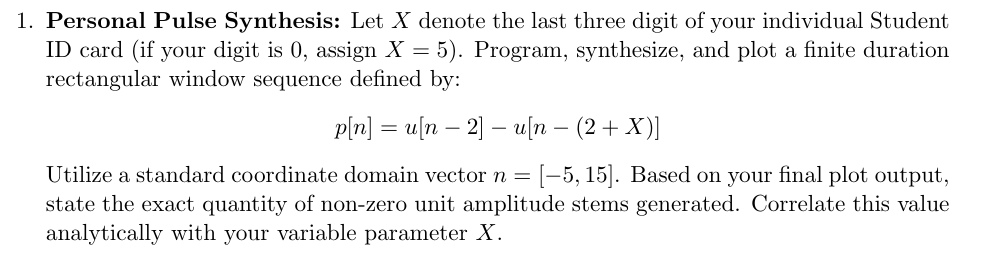**

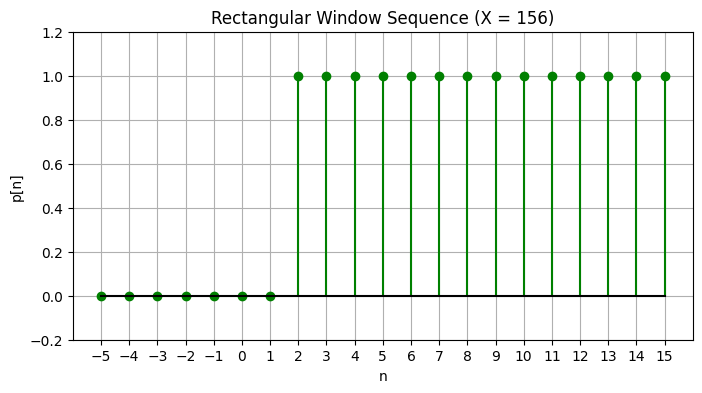

Number of non-zero stems in the plotted range: 14
Theoretical number of non-zero samples = 156


In [7]:
import numpy as np
import matplotlib.pyplot as plt

X = 156
n = np.arange(-5, 16)
u1 = np.where(n >= 2, 1, 0)
u2 = np.where(n >= (2 + X), 1, 0)
p = u1 - u2
non_zero = np.count_nonzero(p)

plt.figure(figsize=(8, 4))
plt.stem(n, p, linefmt='g-', markerfmt='go', basefmt='black')
plt.title(f"Rectangular Window Sequence (X = {X})")
plt.xlabel("n")
plt.ylabel("p[n]")
plt.grid(True)
plt.xticks(n)
plt.ylim(-0.2, 1.2)
plt.show()

print("Number of non-zero stems in the plotted range:", non_zero)
print("Theoretical number of non-zero samples =", X)

# **Task-02**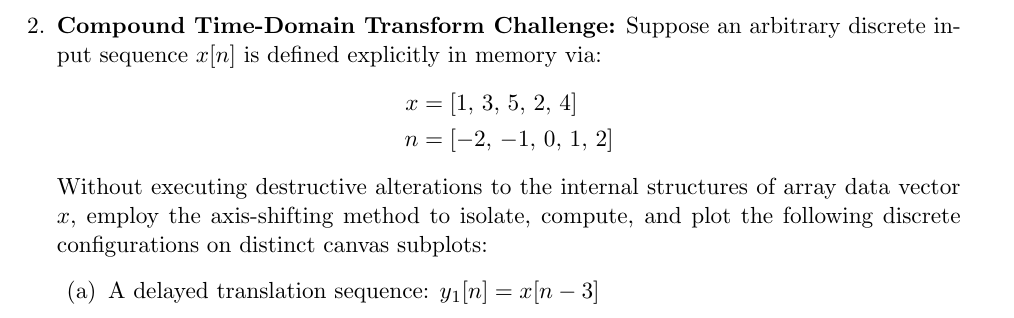
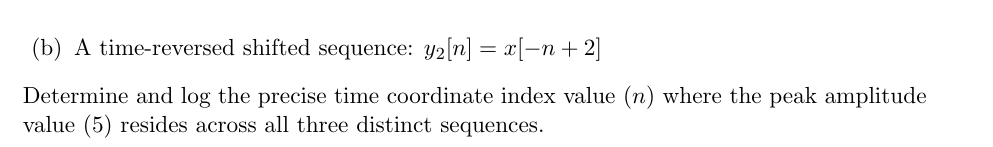

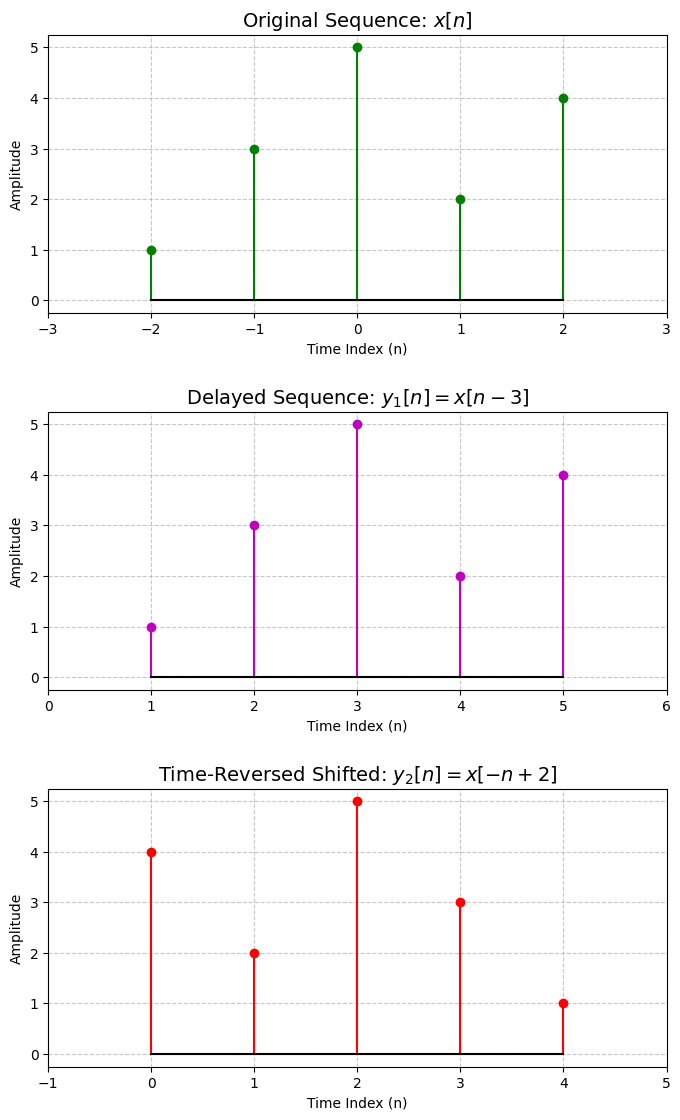

Original sequence x[n] peak at n = 0
Sequence y1[n] peak at n = 3
Sequence y2[n] peak at n = 2


In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 3, 5, 2, 4])
n = np.array([-2, -1, 0, 1, 2])

n1 = n + 3
n2 = -n + 2


fig, axs = plt.subplots(3, 1, figsize=(8, 12))
fig.tight_layout(pad=5.0)

axs[0].stem(n, x, linefmt='g-', markerfmt='go', basefmt="black")
axs[0].set_title("Original Sequence: $x[n]$", fontsize=14)
axs[0].set_xlabel("Time Index (n)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_xticks(np.arange(min(n)-1, max(n)+2, 1))

axs[1].stem(n1, x, linefmt='m-', markerfmt='mo', basefmt="black")
axs[1].set_title("Delayed Sequence: $y_1[n] = x[n-3]$", fontsize=14)
axs[1].set_xlabel("Time Index (n)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_xticks(np.arange(min(n1)-1, max(n1)+2, 1))

axs[2].stem(n2, x, linefmt='r-', markerfmt='ro', basefmt="black")
axs[2].set_title("Time-Reversed Shifted: $y_2[n] = x[-n + 2]$", fontsize=14)
axs[2].set_xlabel("Time Index (n)")
axs[2].set_ylabel("Amplitude")
axs[2].grid(True, linestyle='--', alpha=0.7)
axs[2].set_xticks(np.arange(min(n2)-1, max(n2)+2, 1))

plt.show()

peak_idx = np.where(x == 5)[0][0]
print(f"Original sequence x[n] peak at n = {n[peak_idx]}")
print(f"Sequence y1[n] peak at n = {n1[peak_idx]}")
print(f"Sequence y2[n] peak at n = {n2[peak_idx]}")

# **Task-03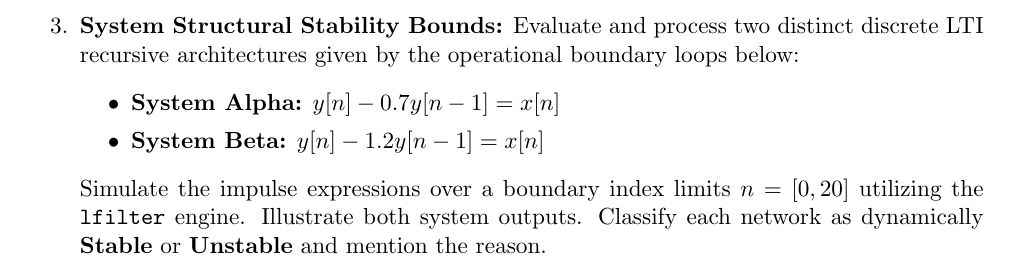**

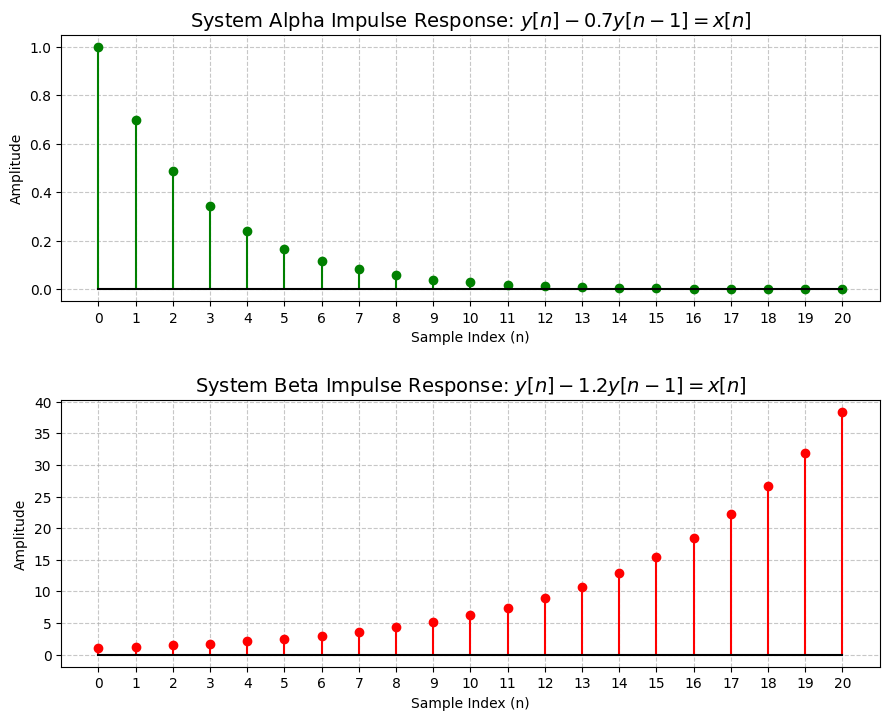

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

n = np.arange(0, 21)
x = np.zeros(len(n))
x[0] = 1

b = [1]
a_alpha = [1, -0.7]
a_beta = [1, -1.2]

y_alpha = lfilter(b, a_alpha, x)
y_beta = lfilter(b, a_beta, x)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
fig.tight_layout(pad=5.0)

axs[0].stem(n, y_alpha, linefmt='g-', markerfmt='go', basefmt="black")
axs[0].set_title("System Alpha Impulse Response: $y[n]-0.7y[n-1] = x[n]$", fontsize=14)
axs[0].set_xlabel("Sample Index (n)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_xticks(n)

axs[1].stem(n, y_beta, linefmt='r-', markerfmt='ro', basefmt="black")
axs[1].set_title("System Beta Impulse Response: $y[n]-1.2y[n-1] = x[n]$", fontsize=14)
axs[1].set_xlabel("Sample Index (n)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_xticks(n)

plt.show()

# **Task-04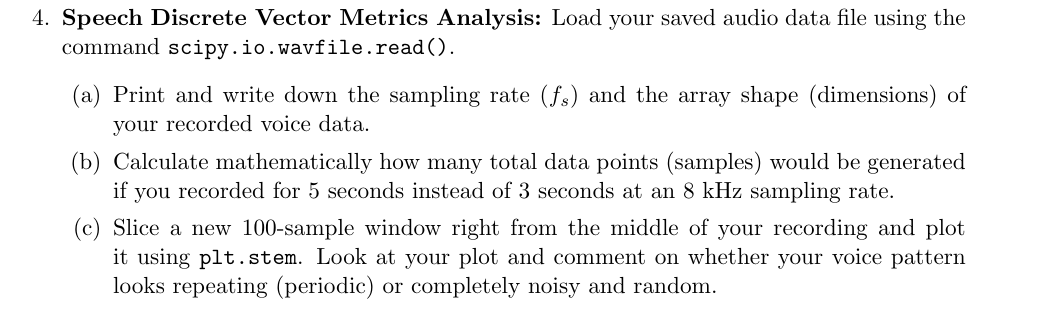**

/tmp/ipykernel_1265/3536370562.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio_data = wavfile.read(audio_filename)


---Part (a)---
Sampling Rate (fs): 44100 Hz
Array Shape (Dimensions): (385123, 2)

---Part (b)---
Calculated Samples (5s @ 8kHz): 40000 samples

---Part (c)---


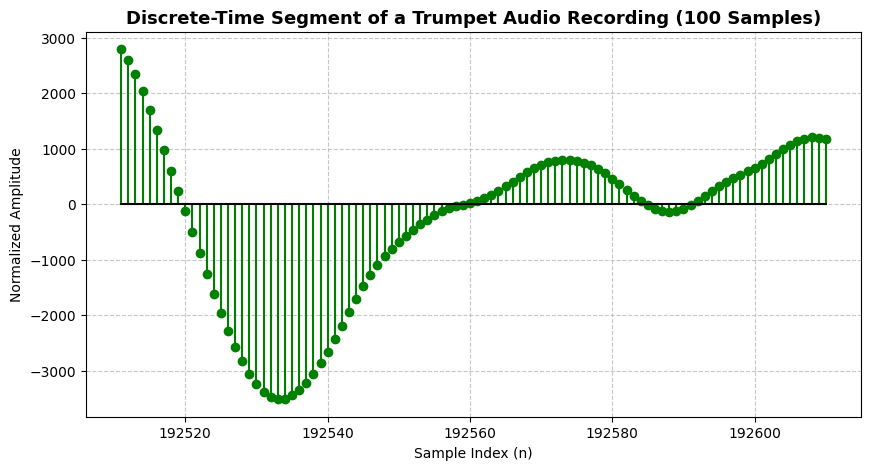

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

audio_filename = "170255__dublie__trumpet.wav"

try:
    fs, audio_data = wavfile.read(audio_filename)

    print("---Part (a)---")
    print(f"Sampling Rate (fs): {fs} Hz")
    print(f"Array Shape (Dimensions): {audio_data.shape}")

    print("\n---Part (b)---")
    time_seconds = 5
    sampling_rate_8khz = 8000
    total_samples = time_seconds * sampling_rate_8khz
    print(f"Calculated Samples (5s @ 8kHz): {total_samples} samples")

    print("\n---Part (c)---")
    if len(audio_data.shape) > 1:
        audio_data = audio_data[:, 0]

    total_length = len(audio_data)
    mid_index = total_length // 2

    start_idx = mid_index - 50
    end_idx = start_idx + 100

    window_100_samples = audio_data[start_idx:end_idx]
    n = np.arange(start_idx, end_idx)

    plt.figure(figsize=(10, 5))
    plt.stem(n, window_100_samples, linefmt='g-', markerfmt='go', basefmt="black")

    plt.title("Discrete-Time Segment of a Trumpet Audio Recording (100 Samples)", fontsize=13, fontweight='bold')
    plt.xlabel("Sample Index (n)")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{audio_filename}' was not found.")